# Project 1 - Apple HBR Report



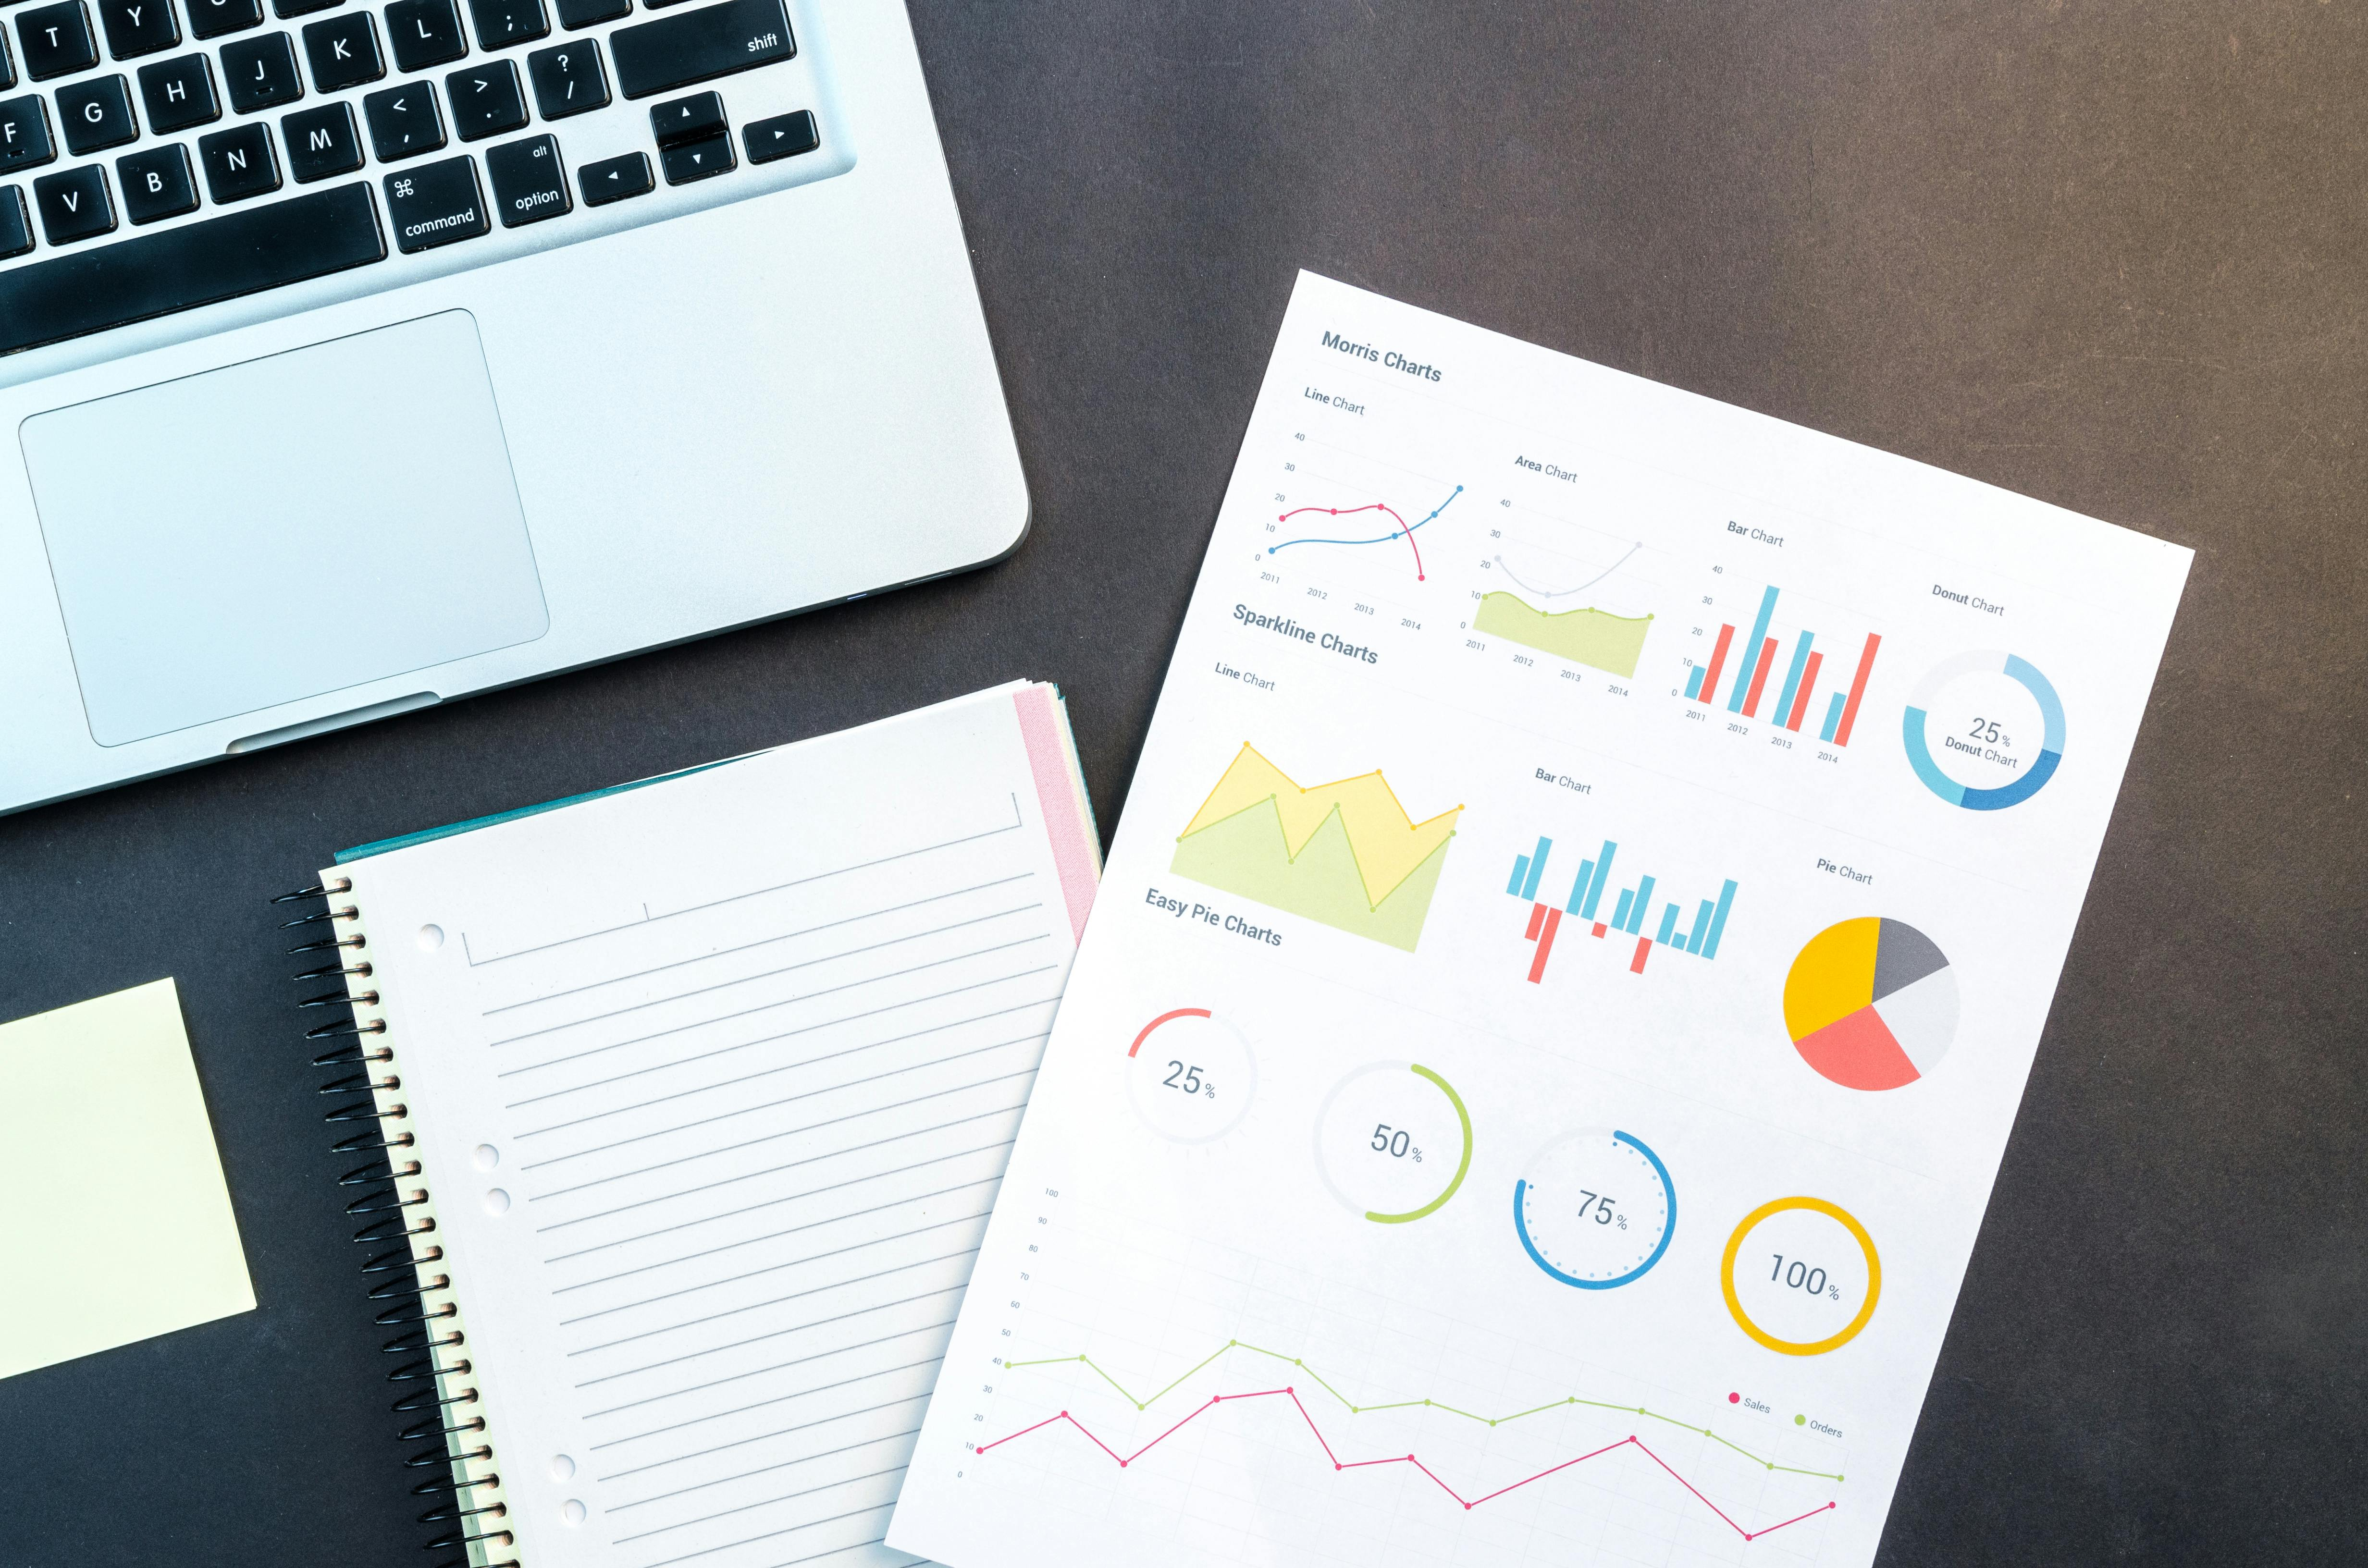

## Business Context
As organizations grow, business analysts increasingly face the challenge of navigating large volumes of reports, research papers, and strategic documents. Extracting the right insights from lengthy materials can be time-consuming and overwhelming, especially when these insights directly influence key business decisions.

Consider joining a venture capital firm like Andreessen Horowitz and being assigned a dense report such as Harvard Business Review’s “How Apple is Organized for Innovation.” Manually reviewing such documents requires significant effort, slowing down the analysis process and increasing the chances of missing important details.

To overcome this information overload, businesses can leverage Semantic Search and Retrieval-Augmented Generation (RAG) models. These systems allow analysts to ask natural-language questions like, “How does Apple structure its teams for innovation?" and instantly retrieve relevant, accurate insights from the source document.

 By integrating such AI-driven retrieval systems, organizations can streamline research workflows, reduce manual effort, and enable analysts to focus on high-value strategic thinking, ultimately improving decision-making speed and quality.

## Objective
As an AI specialist, your task is to develop a RAG-based application that enables business analysts to efficiently extract insights from extensive business reports such as “How Apple is Organized for Innovation.” The objective is to understand the challenges of navigating long, information-dense documents, apply retrieval-augmented generation techniques to surface only the most relevant content, analyze how this improves the speed and accuracy of report interpretation, evaluate its potential to enhance strategic decision-making and productivity for analysts, and create a functional prototype that demonstrates the system’s effectiveness in answering queries, summarizing key insights, and supporting natural-language interactions without requiring users to read the entire report.

## Questions to Answer:
1. Who are the authors of this article and who published this article?

2. List down the three leadership characteristics in bulleted points and explain each one of the characteristics under two lines.

3. Can you explain specific examples from the article where Apple's approach to leadership has led to successful innovations?

## Data Description
**“How Apple is Organized for Innovation”** is a detailed Harvard Business Review article that examines Apple’s unique approach to structuring teams, driving innovation, and maintaining a culture of excellence. The article is provided as a PDF consisting of 11 pages, offering in-depth insights into Apple’s organizational design, leadership principles, and decision-making processes.

## Installing and Importing Necessary Libraries and Dependencies

### Installing Libraries

In [1]:
# Install required libraries
!pip install -q langchain_community==0.3.27 \
              langchain==0.3.27 \
              chromadb==1.0.15 \
              pymupdf==1.26.3 \
              tiktoken==0.9.0 \
              datasets==4.0.0 \
              evaluate==0.4.5 \
              langchain_openai==0.3.30

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.5/19.5 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 459.1/459.1 kB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 k

### Importing Libraries needed for the Project

In [2]:
# Import core libraries
import os                                                                       # Interact with the operating system (e.g., set environment variables)
import json                                                                     # Read/write JSON data
import requests  # type: ignore                                                 # Make HTTP requests (e.g., API calls); ignore type checker

# Import libraries for working with PDFs and OpenAI
from langchain.document_loaders import PyMuPDFLoader                            # Load and extract text from PDF files
# from langchain_community.document_loaders import PyPDFLoader                    # Load and extract text from PDF files
from openai import OpenAI                                                       # Access OpenAI's models and services

# Import libraries for processing dataframes and text
import tiktoken                                                                 # Tokenizer used for counting and splitting text for models
import pandas as pd                                                             # Load, manipulate, and analyze tabular data

# Import LangChain components for data loading, chunking, embedding, and vector DBs
from langchain.text_splitter import RecursiveCharacterTextSplitter              # Break text into overlapping chunks for processing
from langchain.embeddings.openai import OpenAIEmbeddings                        # Create vector embeddings using OpenAI's models  # type: ignore
from langchain.vectorstores import Chroma                                       # Store and search vector embeddings using Chroma DB  # type: ignore

from datasets import Dataset                                                    # Used to structure the input (questions, answers, contexts etc.) in tabular format
from langchain_openai import ChatOpenAI                                         # This is needed since LLM is used in metric computation

## Question Answering using LLM

### Initializing Open API Client

In [4]:
# Load the JSON file and extract values
file_name = "/content/config.json"                                                       # Name of the configuration file
with open(file_name, 'r') as file:                                              # Open the config file in read mode
    config = json.load(file)                                                    # Load the JSON content as a dictionary
    OPENAI_API_KEY = config.get("OPENAI_API_KEY")                                             # Extract the API key from the config
    OPENAI_API_BASE = config.get("OPENAI_API_BASE")                             # Extract the OpenAI base URL from the config

# Store API credentials in environment variables
os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY                                          # Set API key as environment variable
os.environ["OPENAI_BASE_URL"] = OPENAI_API_BASE                                 # Set API base URL as environment variable

# Initialize OpenAI client
client = OpenAI()

print("OpenAI client initialized successfully.")

OpenAI client initialized successfully.


## Defining the function to Generate a Response From the LLM

In [5]:
# Define a function to get a response
def response(user_prompt, max_tokens=1000, temperature=0.75, top_p=0.95):
    # Create a chat completion using the OpenAI client
    completion = client.chat.completions.create(
        model="gpt-4o-mini",                                                     # Specify the model to use
        messages=[
            {"role": "user", "content": user_prompt}                            # User prompt is the input/query to respond to
        ],
        max_tokens=max_tokens,                                                  # Max number of tokens to generate in the response
        temperature=temperature,                                                # Controls randomness in output
        top_p=top_p                                                             # Controls diversity via nucleus sampling
    )
    return completion.choices[0].message.content                                # Return the text content from the model's reply                                                        # Execute the function with the prompts

## Question 1: Who are the authors of this article and who published this article?

In [6]:
question_1 = "Who are the authors of this article and who published this article ?"
base_prompt_response_1=response(question_1)

base_prompt_response_1

"I'm sorry, but I don't have access to external content, such as specific articles or their publication details. If you provide me with the title or some details about the article, I can try to help you in other ways or give general information related to the topic."

## Question 2: List down the three leadership characteristics in bulleted points and explain each one of the characteristics under two lines.

In [7]:
question_2 = "List down the three leadership characteristics in bulleted points and explain each one of the characteristics under two lines" #Complete the code to define the question #2
base_prompt_response_2=response(question_2) #Complete the code to pass the user input

base_prompt_response_2

'- **Vision**: A strong leader possesses a clear and compelling vision for the future, guiding their team towards shared goals and inspiring them to work together effectively.\n\n- **Empathy**: Effective leaders demonstrate empathy by understanding and valuing the perspectives and feelings of their team members, fostering a supportive and inclusive work environment.\n\n- **Decisiveness**: A good leader makes timely and informed decisions, balancing analysis and intuition, which helps to instill confidence and drive progress within their organization.'

## Question 3: Can you explain specific examples from the article where Apple's approach to leadership has led to successful innovations?

In [8]:
question_3 = "Can you explain specific examples from the article where Apple's approach to leadership has led to successful innovations?" #Complete the code to define the question #3
base_prompt_response_3=response(question_3) #Complete the code to pass the user input

base_prompt_response_3

"While I don't have access to specific articles or their contents, I can provide you with a general overview of how Apple's approach to leadership has contributed to successful innovations based on widely known examples.\n\n1. **Product Design and User Experience**: Under the leadership of Steve Jobs, Apple emphasized a commitment to design and user experience. The introduction of the iPod in 2001 revolutionized the music industry by combining a sleek design with an easy-to-use interface. This focus on aesthetics and functionality has continued with products like the iPhone and iPad, which have set industry standards.\n\n2. **Ecosystem Integration**: Apple's leadership has fostered an ecosystem where hardware, software, and services work seamlessly together. The introduction of the App Store in 2008 allowed developers to create applications that enhanced the functionality of the iPhone, further driving its success. This ecosystem approach has led to innovations like Apple Pay and iClou

**Observations:**


*   For Question 1, LLM is not able to find the appropriate answer as the data is not readily available with LLM.
*   For Question 2, LLM doesn't have the right context, its hallucinated with the data and provided answer based on the input.
*   For question 3, LLM doesn't have specific articles but fetched some well known examples from Internet and provided the answers. I don't feel it is giving the correct answer and its hallucinated here again.
*   Overall as the exact data set is not available with LLM, the results received for the questions are not as expected by the user.








## Question Answering using LLM with Prompt Engineering

### Define a system prompt that aligns with the business problem

In [9]:
system_prompt = """
You are an AI assistant specializing in market research knowledge. Your role is to provide clear, precise, and market research responses based on established business research organizations and best practices.

Consider as a business analyst at venture capital firm like Andreessen Horowitz and being assigned a dense report such as Harvard Business Review’s “How Apple is Organized for Innovation.”

When answering, prioritize factual correctness, align with widely accepted business research standards, and ensure clarity for both analysts and general users.
If a query requires specific reference materials beyond general market research knowledge, acknowledge the limitation rather than speculating.

"""

### Defining the function to Generate a Response From the LLM

In [10]:
# Define a function to get a response from the OpenAI chat model
def response(system_prompt, user_prompt, max_tokens=1000, temperature=0.75, top_p=0.95):
    # Create a chat completion using the OpenAI client
    completion = client.chat.completions.create(
        model="gpt-4o-mini",                                                    # Specify the model to use (GPT-4o in this case)
        messages=[
            {"role": "system", "content": system_prompt},                       # System prompt sets the assistant's behavior
            {"role": "user", "content": user_prompt}                            # User prompt is the input/query to respond to
        ],
        max_tokens=max_tokens,                                                  # Max number of tokens to generate in the response
        temperature=temperature,                                                # Controls randomness in output (0 = deterministic)
        top_p=top_p                                                             # Controls diversity via nucleus sampling
    )
    return completion.choices[0].message.content                                # Return the text content from the model's reply

###

### Question 1: Who are the authors of this article and who published this article ?

In [11]:
response_with_prompt_eng_1=response(system_prompt,question_1)
response_with_prompt_eng_1

'The article "How Apple is Organized for Innovation" was authored by David B. Yoffie and Michael A. Cusumano. It was published by the Harvard Business Review. If you need more information or insights related to the content of the article, feel free to ask!'

### Question 2: List down the three leadership characteristics in bulleted points and explain each one of the characteristics under two lines.

In [12]:
response_with_prompt_eng_2 = response(system_prompt, question_2)
response_with_prompt_eng_2

'Certainly! Here are three key leadership characteristics along with brief explanations:\n\n- **Vision**: Effective leaders possess a clear and compelling vision for the future, guiding their teams towards common goals. This vision inspires and motivates employees, fostering a shared sense of purpose.\n\n- **Empathy**: Strong leaders demonstrate empathy by understanding and valuing the feelings and perspectives of their team members. This characteristic builds trust and enhances collaboration, leading to a more cohesive work environment.\n\n- **Decisiveness**: Effective leaders are able to make informed decisions promptly, even in uncertain conditions. This decisiveness instills confidence in their team and ensures that the organization can move forward without unnecessary delays.'

###

### Question 3: Can you explain specific examples from the article where Apple's approach to leadership has led to successful innovations?

In [13]:
response_with_prompt_eng_3 = response(system_prompt, question_3)
response_with_prompt_eng_3

"I don't have direct access to specific articles, including Harvard Business Review’s “How Apple is Organized for Innovation.” However, I can summarize general insights about Apple’s leadership approach and how it has historically contributed to successful innovations based on established business knowledge.\n\nApple's leadership under Steve Jobs and now Tim Cook has emphasized a few key practices that have fostered innovation:\n\n1. **Cross-Functional Collaboration**: Apple organizes teams across different functions (design, engineering, marketing), which allows for diverse perspectives and skills to converge. This collaborative environment has led to the successful development of products like the iPhone, where hardware and software integration was critical.\n\n2. **Strong Vision and Focus**: Apple's leadership has consistently communicated a clear vision, focusing on user experience and design. This is evident in the development of the Apple ecosystem, which includes the seamless in

**Observations**

*   For Question 1, LLM responded with the details found in internet and based on the context provided. But, answer may be right or wrong. LLM might have halucinated too.
*   For Question 2, LLM responded in better way when compared to earlier answers.
* For Question 3, LLM provided similar kind of answer like earlier.
* Overall, the responses are little better but there are chances of LLM hallucinating the responses as the right data is not available with LLM.



## Data Preparation for RAG

### Loading the Data

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
pdf_path = "/content/HBR_How_Apple_Is_Organized_For_Innovation.pdf"
pdf_loader = PyMuPDFLoader(pdf_path)
pdf = pdf_loader.load()

### Data Overview

#### Checking the first 5 pages

In [16]:
for i in range(5):
    print(f"Page Number : {i+1}",end="\n")
    print(pdf[i].page_content,end="\n")

Page Number : 1
REPRINT R2006F
PUBLISHED IN HBR
NOVEMBER–DECEMBER 2020
ARTICLE
ORGANIZATIONAL CULTURE
How Apple Is 
Organized  
for Innovation
It’s about experts leading experts. 
by Joel M. Podolny and Morten T. Hansen
This article is made available to you with compliments of Apple Inc for your personal use. Further posting, copying or distribution is not permitted.
Page Number : 2
2
Harvard Business Review
November–December 2020
This article is made available to you with compliments of Apple Inc for your personal use. Further posting, copying or distribution is not permitted.
Page Number : 3
PHOTOGRAPHER MIKAEL JANSSON
How Apple Is 
Organized 
for Innovation
It’s about experts 
leading experts.
ORGANIZATIONAL 
CULTURE
Joel M. 
Podolny
Dean, Apple 
University
Morten T. 
Hansen
Faculty, Apple 
University
AUTHORS
FOR ARTICLE REPRINTS CALL 800-988-0886 OR 617-783-7500, OR VISIT HBR.ORG
Harvard Business Review
November–December 2020  3
This article is made available to you with compliment

### Data Chunking

#### Chunk the PDF into Manageable Text Sections Using a Token-Based Splitter

In [17]:
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name='cl100k_base',
    chunk_size=256,
    chunk_overlap=20
)

#### Split the Loaded PDF into Chunks for Further Processing

In [18]:
document_chunks = pdf_loader.load_and_split(text_splitter)

#### Check the Number of Chunks Created

In [19]:
len(document_chunks)

42

### Generate Vector Embeddings for Text Chunks Using OpenAI

In [20]:
# Initialize the OpenAI Embeddings model with API credentials
embedding_model = OpenAIEmbeddings(
    openai_api_key=OPENAI_API_KEY,                                                     # Your OpenAI API key for authentication
    openai_api_base=OPENAI_API_BASE                                             # The OpenAI API base URL endpoint
)

# Generate embeddings (vector representations) for the first two document chunks
embedding_1 = embedding_model.embed_query(document_chunks[0].page_content)      # Embedding for chunk 0
embedding_2 = embedding_model.embed_query(document_chunks[1].page_content)      # Embedding for chunk 1

# Check and print the dimension (length) of the embedding vector
print("Dimension of the embedding vector ", len(embedding_1))                   # Typically 1536 or 2048 depending on model

/tmp/ipykernel_1799/145305138.py:2: LangChainDeprecationWarning: The class `OpenAIEmbeddings` was deprecated in LangChain 0.0.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import OpenAIEmbeddings``.
  embedding_model = OpenAIEmbeddings(


Dimension of the embedding vector  1536


In [21]:
# Verify if both embeddings have the same dimension (should be True)
len(embedding_1) == len(embedding_2)

# Return/display the two embedding vectors for further inspection or use
embedding_1, embedding_2

([0.0025246840760870756,
  -0.005738068657514522,
  -0.0031388859895014093,
  -0.011899953368824125,
  0.017455913995005092,
  0.030461761753468375,
  -0.010211312720124025,
  0.018065149863373844,
  -0.013694548729464963,
  -0.021495408516744415,
  0.0029650553207922425,
  0.009257726831915744,
  -0.007906813567897566,
  -0.006651921528745025,
  -0.03361389208196238,
  0.01983987824986448,
  0.024091280332840033,
  -0.012893272274010182,
  -0.000846803870741817,
  -0.0019022045672176995,
  -0.03361389208196238,
  -0.0015065328501972029,
  -0.004450066236541811,
  0.009171639094125206,
  0.008939864558738778,
  0.0004747233706173879,
  0.015972559203706237,
  -0.02084644056272051,
  0.029243291879376118,
  -0.0057976681829811855,
  0.01960148201064307,
  0.017204274348113707,
  -0.011701290146580487,
  0.001273103005267355,
  -0.009847095726134295,
  -0.025746810599719967,
  -0.007986279601853118,
  -0.02309796142765398,
  0.024912423762445016,
  -0.0384083074070211,
  0.04071280562792

### Vector Database

#### Setup Vector Database Directory

In [22]:
out_dir = '/content/hbr_report_database'    # complete the code to define the name of the vector database

if not os.path.exists(out_dir):
  os.makedirs(out_dir)

#### Create Vector Database from Documents

In [23]:
# Building the vector store and saving it to disk for future use
vectorstore = Chroma.from_documents(
    document_chunks,                                                            # Documents to index
    embedding_model,                                                            # Embedding model for converting text to vectors
    persist_directory=out_dir                                                   # Save vector DB files here
)

#### Load Vector Database

In [24]:
vectorstore = Chroma(
    persist_directory=out_dir,
    embedding_function=embedding_model
)

/tmp/ipykernel_1799/3612695989.py:1: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  vectorstore = Chroma(


#### Explore Vector Database and Perform Searches

In [25]:
vectorstore.embeddings

OpenAIEmbeddings(client=<openai.resources.embeddings.Embeddings object at 0x7f7c052d1eb0>, async_client=<openai.resources.embeddings.AsyncEmbeddings object at 0x7f7c052ff3b0>, model='text-embedding-ada-002', deployment='text-embedding-ada-002', openai_api_version='', openai_api_base='https://aibe.mygreatlearning.com/openai/v1', openai_api_type='', openai_proxy='', embedding_ctx_length=8191, openai_api_key='gl-U2FsdGVkX1/plvqFWOfpZp+oSbx+/igvGyOMlU4zKcmqmVLdQjE2/duTcZt7a1xP', openai_organization=None, allowed_special=set(), disallowed_special='all', chunk_size=1000, max_retries=2, request_timeout=None, headers=None, tiktoken_enabled=True, tiktoken_model_name=None, show_progress_bar=False, model_kwargs={}, skip_empty=False, default_headers=None, default_query=None, retry_min_seconds=4, retry_max_seconds=20, http_client=None)

**Search for top 3 most relevant chunk for the query**

In [26]:
vectorstore.similarity_search(
    "List down the three leadership characteristics in bulleted points and explain each one of the characteristics under two lines.",
    k=3
)

[Document(metadata={'keywords': '', 'creator': 'Adobe InDesign 14.0 (Macintosh)', 'author': '', 'trapped': '', 'moddate': '2020-12-01T18:37:49+00:00', 'encryption': 'Standard V2 R3 128-bit RC4', 'format': 'PDF 1.6', 'total_pages': 11, 'title': '', 'source': '/content/HBR_How_Apple_Is_Organized_For_Innovation.pdf', 'creationdate': '2020-10-05T14:18:42-04:00', 'file_path': '/content/HBR_How_Apple_Is_Organized_For_Innovation.pdf', 'creationDate': "D:20201005141842-04'00'", 'modDate': 'D:20201201183749Z', 'subject': '', 'producer': 'Adobe PDF Library 15.0 (via http://bfo.com/products/pdf?version=2.23.5-r33279)', 'page': 5}, page_content='fundamental principle of a conventional business unit struc-\nture is to align accountability and control, the fundamental \nprinciple of a functional organization is to align expertise and \ndecision rights.\nThus the link between how Apple is organized and \nthe type of innovations it produces is clear. As Chandler \nfamously argued, “structure follows s

### Retrieval and Response Generation using Vector Search

#### Convert Vector Database into a Retriever and Retrieve Relevant Documents

In [27]:
retriever = vectorstore.as_retriever(
    search_type='similarity',
    search_kwargs={'k': 3} #Complete the code to pass an appropriate k value
)

### System and User Prompt Template

#### Prompts guide the model to generate accurate responses. Here, we define two parts:

1. The system message describing the assistant's role.
2. A user message template including context and the question.

In [28]:
qna_system_message = """
You are an AI assistant designed to support professional business analysts at a venture capital firm like Andreessen Horowitz . Your task is to provide evidence-based, concise, and relevant business research information to business analysts based on the context provided.

User input will include the necessary context for you to answer their questions. This context will begin with the token: ###Context. The context contains references to specific portions of business research literature and research articles relevant to the query, along with their source details.

When crafting your response:
1. Use only the provided context to answer the question.
2. If the answer is found in the context, respond with concise and actionable business research information.
3. Include the source reference with the page number, journal name, or publication, as provided in the context.
4. If the question is unrelated to the context or the context is empty, clearly respond with: "Sorry, this is out of my knowledge base."

Adhere to the following response guidelines:
- Provide clear, direct answers using only the given context.
- Do not include any additional information outside of the context.
- Avoid rephrasing or summarizing the context unless explicitly relevant to the question.
- If no relevant answer exists in the context, respond with: "Sorry, this is out of my knowledge base."
- If the context is not provided, your response should also be: "Sorry, this is out of my knowledge base."

Here is an example of how to structure your response:

Answer:
[Business Reasearch answer based on context]

Source:
[Source details with page or section]
"""

In [29]:
qna_user_message_template = """
###Context
Here are some excerpts from business reasearch and their sources that are relevant to the business reasearch mentioned below:
{context}

###Question
{question}
"""

### Response Function

In [32]:
def generate_rag_response(user_input,k=5,max_tokens=128,temperature=0,top_p=0.95):
    global qna_system_message,qna_user_message_template
    # Retrieve relevant document chunks
    relevant_document_chunks = retriever.get_relevant_documents(query=user_input,k=k)
    context_list = [d.page_content for d in relevant_document_chunks]

    # Combine document chunks into a single context
    context_for_query = ". ".join(context_list)

    user_message = qna_user_message_template.replace('{context}', context_for_query)
    user_message = user_message.replace('{question}', user_input)

    # Generate the response
    try:
        response = client.chat.completions.create(
        model="gpt-4o-mini",   # Complete the code by specifying the model to be used.
        messages=[
            {"role": "system", "content": qna_system_message},
            {"role": "user", "content": user_message}
        ],
        max_tokens=max_tokens,
        temperature=temperature,
        top_p=top_p
        )
        # Extract and print the generated text from the response
        response = response.choices[0].message.content.strip()
    except Exception as e:
        response = f'Sorry, I encountered the following error: \n {e}'

    return response

## Question Answering using RAG

### Question 1: Who are the authors of this article and who published this article ?

In [33]:
response_with_rag_1 = generate_rag_response(question_1)
response_with_rag_1

'Answer:\nThe authors of the article are Joel M. Podolny and Morten T. Hansen. The article is published by Harvard Business Review.\n\nSource:\nHarvard Business Review, November–December 2020.'

### Question 2: List down the three leadership characteristics in bulleted points and explain each one of the characteristics under two lines.

In [34]:
response_with_rag_2 = generate_rag_response(question_2)
response_with_rag_2

'Answer:\n- **Deep Expertise**: Leaders are expected to possess in-depth knowledge of their specific functions, enabling them to engage meaningfully in the work and make informed decisions.\n\n- **Immersion in Details**: Leaders should understand the intricacies of their organization at least three levels down, which is crucial for effective and swift cross-functional decision-making.\n\n- **Willingness to Collaboratively Debate**: Leaders must be open to discussing and debating ideas with others, advocating for their views while being receptive to changing their minds based on evidence and collaborative input.\n\nSource:\n[Source details not provided in the context]'

### Question 3: Can you explain specific examples from the article where Apple's approach to leadership has led to successful innovations?

In [35]:
response_with_rag_3 = generate_rag_response(question_3)
response_with_rag_3

"Answer:\nThe article highlights that Apple's approach to leadership, characterized by having leaders who are experts in their areas, has led to successful innovations through collaborative efforts. For instance, the development of the dual-lens camera with portrait mode required collaboration among hundreds of specialist teams, demonstrating how deep expertise and cross-functional collaboration are essential for innovation at Apple. This structure allows leaders to engage in detailed discussions, focus on critical issues, and provide better guidance, which is seen as liberating and exhilarating by employees.\n\nSource:\nPodolny, J. M., & Hansen, M. T. (2020). How Apple Is Organized for Innovation. Harvard"

**Observations**


Question 1 - Authors and publisher

RAG answer provides clear and correct.

Question 2 - Three leadership characters

RAG answer presents a well-structured leadership characters in two lines for each leadership character.

Question 3 - Successful Innovations

RAG answer highlighting the Apple's approach to leadership with an example.



### Actionable Insights and Business Recommendations

1. **Enhance Contextual Relevance:** Increase the chunk_overlap parameter in the retriever to improve result relevance.

2. **Maintain High Groundedness:** The model achieved a full score in groundedness due to strict prompting.

3. **Optimize Embeddings for Domain-Specific Accuracy:** While the current embedding model performs well, switching to a model pre-trained on business research datasets can further improve document retrieval relevance.

4. **Continuous Knowledge Update:** Regularly update the knowledge base to include the latest market research and guidelines, ensuring the chatbot remains accurate and relevant.   

5. **Feedback Integration:** Incorporate a feedback mechanism for business analysts to refine the chatbot’s responses and adapt to real-world business reseaarch reports effectively.  

6. **Scalability for Other Specializations:** Expand the RAG system to support additional research specialties, broadening its utility across the market research ecosystem.



<font size=6 color='#4682B4'>Power Ahead</font>
___